In [1]:
import sys
import os

# Add the src folder to the system path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, project_root)

# Confirm the path was added
print("Updated sys.path:", sys.path[:2])  # should show the src path at the top



Updated sys.path: ['/Users/jawayria/Desktop/EDISS/DIE/temp3/ADES-reliability-estimation/src', '/Users/jawayria/Desktop/EDISS/DIE/temp3']


In [2]:
from datamanip.datasetmanip.feature_extraction import get_meta_features_from_ensemble
from torchmetrics.functional.classification import multiclass_roc
!python --version

Python 3.11.8


In [3]:
import importlib

import utils
importlib.reload(utils)
import train_eval.load_models
importlib.reload(train_eval.load_models)

from train_eval.load_models import load_best_model_based_on_match, load_best_ensemble

import torch
from torch_geometric.loader import DataLoader
from filepath import *
from datamanip.datasetmanip.three_five_dataset import ThreeFiveDataset
from datamanip.plots import generate_matrix, visualize_samples_outside_of_radii

In [4]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [5]:
train_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="train")
test_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="test")
val_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="val")
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)

In [6]:
ensemble = load_best_ensemble(multiclass_included=True)

Using GAT_LN_HEAD for match 1-1, using 4 heads
Using GAT_LN_HEAD for match 2-1, using 4 heads
Using GAT_LN_HEAD for match 2-2, using 4 heads
Using GAT for match 3-1
Using GAT_LN_HEAD for match 3-2, using 8 heads
Using GAT_LN_HEAD for match 3-3, using 4 heads
Using GAT_LN_HEAD for match 3-4, using 4 heads
Using GAT_LN_HEAD for match ensemble, using 4 heads


In [7]:
# Function to collect predictions from base models
def construct_meta_learning_dataset(loader):
    meta_features, labels = [], []
    for data in loader:
        outputs = get_meta_features_from_ensemble(ensemble, data)
        meta_features.append(outputs)
        labels.append(data.y.cpu().numpy())
    return np.vstack(meta_features), np.hstack(labels)

In [ ]:
'''
def get_meta_features(loader):
    meta_features = []
    true_labels = []
    for data in loader:
        batch_size = data.num_graphs
        batch_features = [[] for _ in range(batch_size)]
        for model in ensemble.values():
            with torch.no_grad():
                output = model(data)
                probs = torch.sigmoid(output).squeeze().cpu().numpy()
                if probs.ndim == 0:
                    probs = np.expand_dims(probs, axis=0)
                preds = (probs >= 0.5).astype(int)
                confidences = np.abs(probs - 0.5)
                for i in range(batch_size):
                    batch_features[i].append([probs[i], preds[i], confidences[i]])
        meta_features.extend(batch_features)
        true_labels.extend(data.y.cpu().numpy())
    return np.array(meta_features), np.array(true_labels)
'''

In [8]:
meta_X_train, meta_y_train = construct_meta_learning_dataset(train_loader)

In [10]:
meta_X_train.shape, meta_y_train.shape

((52043, 22), (52043,))

In [12]:
meta_X_train[0]

array([9.9999630e-01, 4.2204297e-06, 6.6652066e-01, 4.5840451e-01,
       9.9856645e-01, 1.3273825e-03, 1.1560127e-02, 9.8747104e-01,
       9.9973518e-01, 1.7555313e-04, 9.9685377e-01, 5.3530140e-03,
       9.9999988e-01, 5.5347474e-08, 2.6852344e-05, 8.2828033e-01,
       1.7169283e-01, 2.3764854e-10, 5.6791329e-21, 1.1081403e-25,
       5.5759095e-25, 7.9838356e-24], dtype=float32)

In [ ]:
'''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Define and train the meta-learner
meta_learner = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

meta_learner.fit(meta_X_train, meta_y_train)
'''

In [13]:
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)
meta_learner.fit(meta_X_train, meta_y_train)

with open(os.path.join(meta_learner_model_path, 'forest_model.pkl'), 'wb') as f:
    pickle.dump(meta_learner, f)

In [14]:
meta_X_test, meta_y_test = construct_meta_learning_dataset(test_loader)

In [15]:
test_preds = meta_learner.predict(meta_X_test)

In [16]:
accuracy = accuracy_score(meta_y_test, test_preds)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9676936366253959


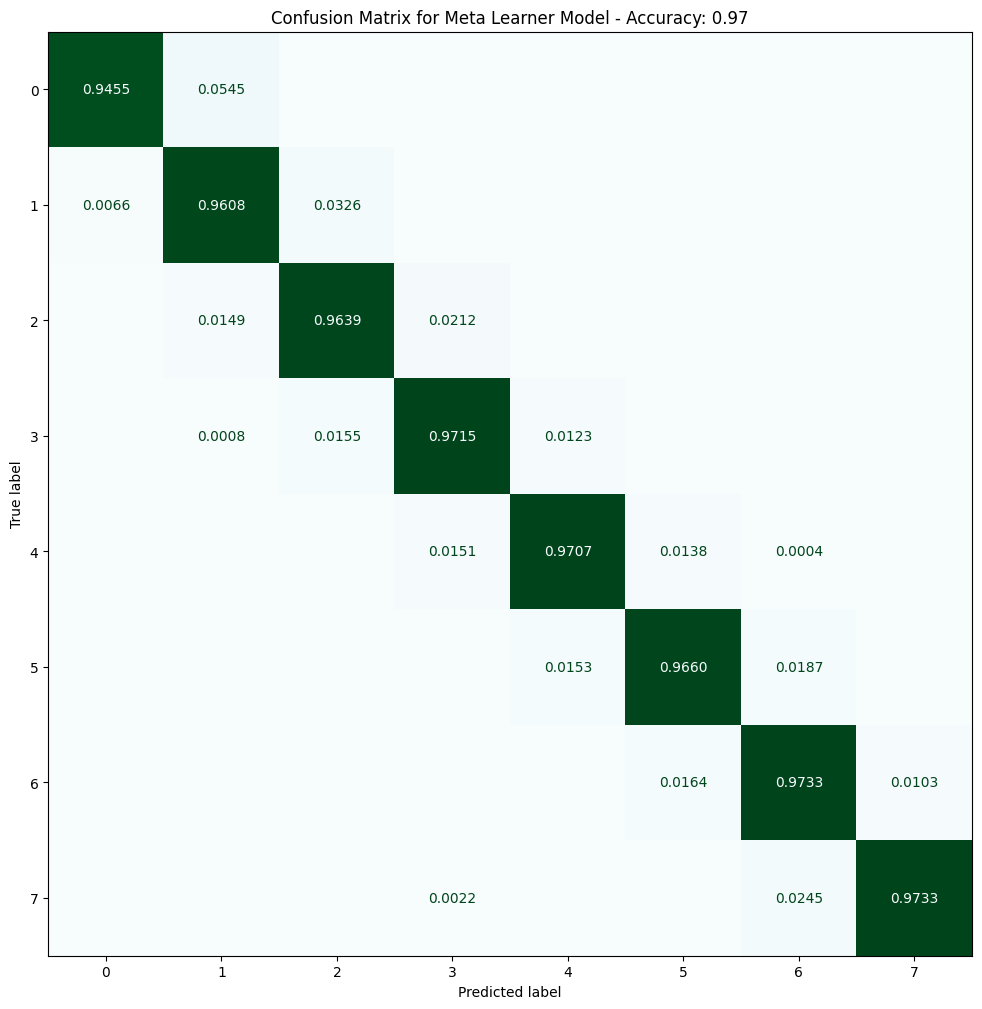

In [17]:
generate_matrix(meta_y_test, test_preds, accuracy, "Meta Learner Model")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define parameter grid
param_grid = {'n_estimators': [50, 100, 200, 300, 500]}

# Define the classifier
rf = RandomForestClassifier(random_state=42)

# Perform grid search
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(meta_X_train, meta_y_train)

# Best hyperparameter and best model
best_n_estimators = grid_search.best_params_['n_estimators']
best_rf_model = grid_search.best_estimator_

print(f"Best n_estimators: {best_n_estimators}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred = best_rf_model.predict(meta_X_test)
test_accuracy = accuracy_score(meta_y_test, y_pred)

print(f"Test set accuracy: {test_accuracy:.4f}")


In [ ]:
generate_matrix(meta_y_test, y_pred, accuracy, "Ensemble Model")

In [ ]:
outside_1 = np.sum(np.abs(np.array(meta_y_test) - np.array(y_pred)) > 1) / len(meta_y_test)
outside_2 = np.sum(np.abs(np.array(meta_y_test) - np.array(y_pred)) > 2) / len(meta_y_test)

In [ ]:

visualize_samples_outside_of_radii(accuracy, outside_1, outside_2)

In [ ]:

from sklearn.model_selection import GridSearchCV, validation_curve
n_estimators_range = [50, 100, 200, 300, 500]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    meta_X_train, meta_y_train,
    param_name="n_estimators",
    param_range=n_estimators_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

# Compute mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot the validation curve
plt.figure(figsize=(8, 6))
plt.plot(n_estimators_range, train_mean, label="Training Score", color="blue", marker='o')
plt.fill_between(n_estimators_range, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)

plt.plot(n_estimators_range, val_mean, label="Validation Score", color="red", marker='o')
plt.fill_between(n_estimators_range, val_mean - val_std, val_mean + val_std, color="red", alpha=0.2)

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Validation Curve for Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV with a 5-fold cross-validation
grid_search = GridSearchCV(estimator=meta_learner, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(meta_X_train, meta_y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_


meta_X_test, meta_y_test = construct_meta_learning_dataset(test_loader)
# Use it to make predictions on the test set
y_pred = best_rf.predict(meta_X_test)
test_accuracy = accuracy_score(meta_y_test, y_pred)

print(f"Test set accuracy: {test_accuracy:.4f}")
